# Feature Engineering

**Project:** Income Prediction: What Determines Who Earns More? (2.4)

**Team:** Anastasia Sidorova and Paola Cancino

**Date:** 4/01/2026

In [1]:
## import libraries

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load Preprocessed Data

In [4]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv')
y_test = pd.read_csv('data/processed/y_test.csv')
print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 38,080 rows x 12 columns
y_train Loaded: 38,080 rows x 1 columns
X_test Loaded: 9,512 rows x 12 columns
y_test Loaded: 9,512 rows x 1 columns


In [6]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

print("\nNumeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numeric columns: 5
Categorical columns: 7


In [8]:
X_train.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,51,Self-emp-not-inc,13.0,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States
1,45,Private,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States
2,17,Private,6.0,Never-married,Sales,Other-relative,White,Male,0,0,30,United-States
3,28,Private,9.0,Never-married,Other-service,Own-child,White,Female,0,0,32,United-States
4,26,Private,7.0,Divorced,Craft-repair,Not-in-family,White,Female,0,0,40,United-States


In [10]:
y_train

,income
0,0
1,1
2,0
3,0
4,0
...,...
38075,0
38076,0
38077,0
38078,0


### Observations:
* X_train has 38,080 rows and 12 columns
* X_test has 9,512 rows and 12 columns
* There are 5 numeric columns and 7 categorical columns
* Planned feature engineering columns: age, education-num, hours-per-week, and capital-gain/loss

## 2. Create New Features

### Log Transformation

In [15]:
for col in ['capital-gain', 'capital-loss']:
    X_train[col + '_log'] = np.log1p(X_train[col])
    X_test[col + '_log'] = np.log1p(X_test[col])
X_train['capital-gain_log'].describe()
X_train['capital-loss_log'].describe()

count    38080.000000
mean         0.347422
std          1.578749
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.379539
Name: capital-loss_log, dtype: float64

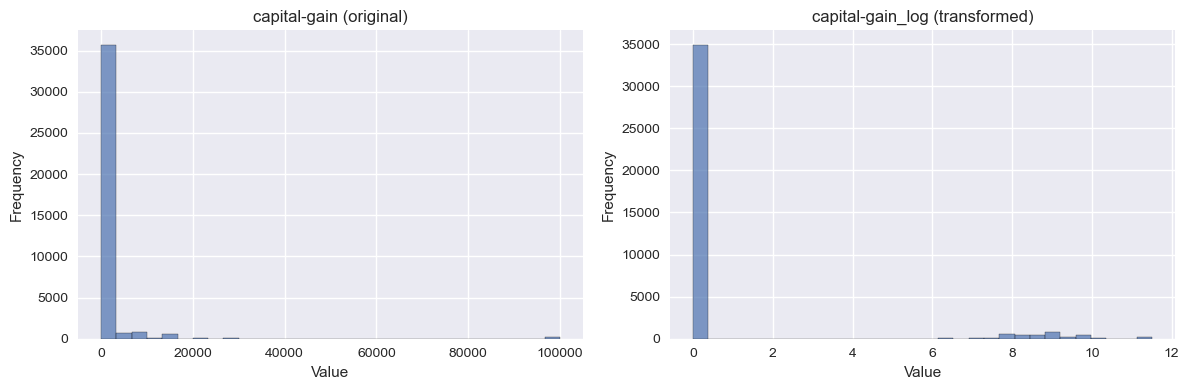

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original
axes[0].hist(X_train['capital-gain'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('capital-gain (original)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(X_train['capital-gain_log'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('capital-gain_log (transformed)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [19]:
print(f'\nTotal features now: {X_train.shape[1]}')


Total features now: 14


### Explanation: 
* We applied a log transformation to the capital-gain column using np.log1p() to reduce right skewness.
* After transformation, the majority of values remain at 0, while the maximum value is reduced to 11.51, confirming that extreme values were compressed.
* This transformation helps improve model performance by stabilizing variance and reducing the influence of outliers.

### Ratio Features

In [23]:
X_train['hours_per_edu'] = X_train['hours-per-week'] / (X_train['education-num'] + 1)
X_test['hours_per_edu'] = X_test['hours-per-week'] / (X_test['education-num'] + 1)

X_train['gain_per_hour'] = X_train['capital-gain'] / (X_train['hours-per-week'] + 1)
X_test['gain_per_hour'] = X_test['capital-gain'] / (X_test['hours-per-week'] + 1)

X_train['hours_per_edu'].describe()

count    38080.000000
mean         3.824010
std          1.490645
min          0.066667
25%          2.857143
50%          3.636364
75%          4.285714
max         18.000000
Name: hours_per_edu, dtype: float64

### Explanation: 
* We created the hours_per_edu feature by dividing hours-per-week by education-num, representing how many hours a person works based on their level of education.
* This feature could capture workload intensity or efficiency, which could have an effect on income levels.
* The feature has a mean of 3.82 and a median of 3.64-- a fairly centered distribution. The values range from 0.07 to 18, with most observations falling between 2.86 and 4.29 (interquartile range)-- feature has no extreme outliers.

### Binning

In [27]:
age_bins = [0, 25, 45, 65, 100]
age_labels = ['young', 'middle', 'senior', 'older']

# TODO: create age groups
X_train['age_groups'] = pd.cut(X_train['age'], bins= age_bins, labels=age_labels)
print('Age groups created:')
print(X_train['age_groups'].value_counts().sort_index())

Age groups created:
age_groups
young      7356
middle    19466
senior     9924
older      1334
Name: count, dtype: int64


### Explaination: 
* We created the age_bin feature by grouping the continuous age variable into four categories representing different life stages.
* Binning helps capture non-linear relationships between age and income.
* The value counts show that most individuals fall into the 26–45 group (19,466) and 46–65 group (9,924), while fewer observations are in the youngest (7,356) and oldest (1,334) groups.

### Interaction Feature

In [31]:
X_train['age_hours_interaction'] = X_train['age'] * X_train['hours-per-week']
X_test['age_hours_interaction'] = X_test['age'] * X_test['hours-per-week']

X_train['age_hours_interaction'].describe()

count    38080.000000
mean      1581.099527
std        739.358602
min         21.000000
25%       1080.000000
50%       1520.000000
75%       2035.000000
max       8910.000000
Name: age_hours_interaction, dtype: float64

### Explaination: 
* We created the age_hours_interaction feature by multiplying age and hours-per-week--we want to see the effect of age and working hours on income.
* The summary statistics show a mean of 1581.10 and a median of 1520-- pretty centered distribution. Values range from 21 to 8910, with most observations between 1080 and 2035 (interquartile range)-- feature has no extreme outliers.


### Binary Flag

In [35]:
X_train['high_hours_flag'] = (X_train['hours-per-week'] > 40).astype(int)
X_test['high_hours_flag'] = (X_test['hours-per-week'] > 40).astype(int)

In [37]:
X_train['high_hours_flag'].value_counts()

high_hours_flag
0    26803
1    11277
Name: count, dtype: int64

### Explaination:
* We created the high_hours_flag feature as a binary indicator for if people worked more than 40 hours per week (1 = more than 40 hours, 0 = 40 hours or less).
* This feature helps capture the potential impact of working overtime or full-time hours on income.
* The value counts show that 11,277 individuals work more than 40 hours, while 26,803 work 40 hours or less.

## 3. Encode Categorical Features

In [41]:
X_train = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, drop_first=True, dtype=int)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("\nRemaining object columns:")
print(X_train.select_dtypes(include='object').shape)


Remaining object columns:
(38080, 0)


In [43]:
X_train.shape


(38080, 93)

### Observation:
* We applied one-hot encoding to all categorical (object) variables using pd.get_dummies() with drop_first=True.
* We dropped the first category to prevent multicollinearity.
* All encoded columns were converted to integer type.
* After encoding, the dataset contains 94 total columns.

## 4. Scale Numerical Features

In [47]:
num_cols = X_train.select_dtypes(include=np.number).columns

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\nScaled column means (should be ~0):")
print(X_train_scaled[num_cols].mean().head())


Scaled column means (should be ~0):
age              -2.302547e-16
education-num    -1.414368e-16
capital-gain      3.172066e-17
capital-loss      3.731842e-17
hours-per-week    1.992804e-16
dtype: float64


### Observation: 
* We scaled the following numerical columns: age, education-num, capital-gain, capital-loss, and hours-per-week.
* These columns were scaled because they are continuous numerical variables with different ranges.
* All means are extremely close to 0.

## 5. Feature Selection


Top correlations with target:
marital-status_Married-civ-spouse    0.348520
education-num                        0.269090
marital-status_Never-married         0.249229
age_hours_interaction                0.248258
capital-gain_log                     0.230242
high_hours_flag                      0.187016
age                                  0.184379
relationship_Own-child               0.177495
hours-per-week                       0.174755
capital-gain                         0.171613
sex_Male                             0.170179
gain_per_hour                        0.167417
occupation_Exec-managerial           0.163994
relationship_Not-in-family           0.150152
Name: income, dtype: float64


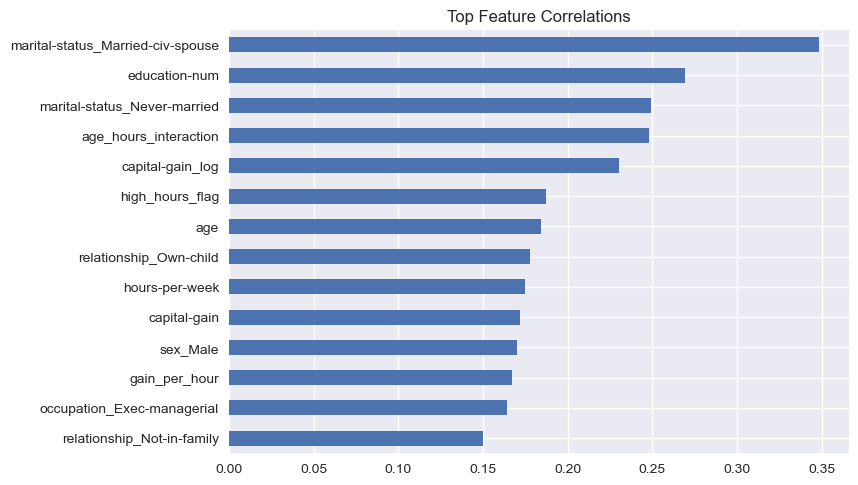

In [51]:
corr = X_train_scaled.join(y_train).corr(numeric_only=True)

target_corr = corr['income'].abs().sort_values(ascending=False)[1:15]

print("\nTop correlations with target:")
print(target_corr)

# Plot
plt.figure()
target_corr.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top Feature Correlations')
plt.show()


In [53]:
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("\nHigh correlation pairs (>0.8):")
for pair in high_corr_pairs:
    print(pair)



High correlation pairs (>0.8):
('capital-loss_log', 'capital-loss', 0.9854762140328207)
('gain_per_hour', 'capital-gain', 0.9166694374573647)


### Observation: 
* The three features most correlated with the income are:marital-status_Married-civ-spouse (0.3485), education-num (0.2691), and marital-status_Never-married (0.2492)
* Several engineered features performed strongly and, in some cases, outperformed their original variables-- like age_hours_interaction (0.2483) performs better than age (0.1844) and capital-gain_log (0.2302) improves upon the raw capital-gain (0.1716)-- log transformation worked well.
* The highly correlated feature pairs (|r| > 0.8) are capital-loss_log and capital-loss (0.9855) gain_per_hour and capital-gain (0.9167).
* In the modeling process, we will work on multicllinearity. For this, we will keep the feature capital-gain_log and will drop any other potentially unessesary vairables. 

## 6. SMOTE + Save Final Data 

In [57]:
y_train.value_counts()

income
0         31809
1          6271
Name: count, dtype: int64

In [59]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [64]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

Before SMOTE:
income
0         31809
1          6271
Name: count, dtype: int64

After SMOTE:
income
0         31809
1         31809
Name: count, dtype: int64


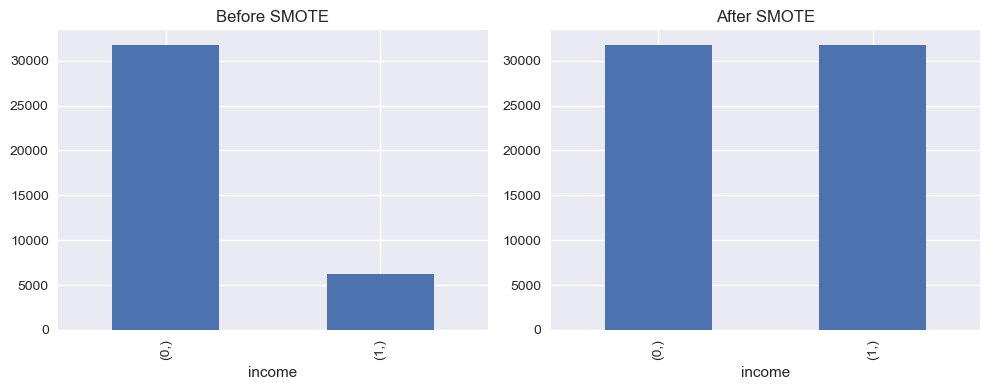

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
y_train.value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Before SMOTE')

# After
y_train_sm.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('After SMOTE')

plt.tight_layout()
plt.show()

In [68]:
# Without SMOTE
X_train.to_csv('X_train_no_smote.csv', index=False)

# With SMOTE
X_train_sm.to_csv('X_train_smote.csv', index=False)

In [70]:
print("\nPre-save checks:")
print("Same columns:", (X_train_scaled.columns == X_test_scaled.columns).all())
print("Missing values:", X_train_scaled.isnull().sum().sum(), X_test_scaled.isnull().sum().sum())
print("Object columns:", X_train_scaled.select_dtypes(include='object').shape)

# Save
X_train_scaled.to_csv('data/modeling/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('data/modeling/X_test_scaled.csv', index=False)

y_train.to_csv('data/modeling/y_train.csv', index=False)
y_test.to_csv('data/modeling/y_test.csv', index=False)

print("\nFiles saved successfully!")


Pre-save checks:
Same columns: True
Missing values: 0 0
Object columns: (38080, 0)

Files saved successfully!


### Observation: 
* The target variable was highly imbalanced with the ration approx at 5:1, thus we applied SMOTE to the training data.
* After applying SMOTE, both classes are balanced.

### Key Findings Summary
1.  Started with original features; added multiple engineered features (log transformations, ratios, interactions, and bins); final dataset contains 94 total features after encoding.
2.  Strongest predictors: marital-status_Married-civ-spouse (r = 0.3485).
3.  Engineered features improved performance: capital-gain_log (r = 0.2302) outperformed capital-gain (r = 0.1716).
4.  Classification class ratio was 5:1 before SMOTE and 1:1 after SMOTE-- 25,538 rows added. 